In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/AI and Machine Learning/Copy of FruitinAmazon.zip" /content/

In [3]:
!ls /content/

'Copy of FruitinAmazon.zip'   drive   sample_data


In [4]:
!unzip "/content/Copy of FruitinAmazon.zip" -d /content/dataset

Archive:  /content/Copy of FruitinAmazon.zip
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: /content/dataset/FruitinAmazon/tes

In [5]:
!ls /content/dataset

FruitinAmazon


In [6]:
!ls /content/dataset/FruitinAmazon

test  train


Task 1: Data Understanding and Visualization

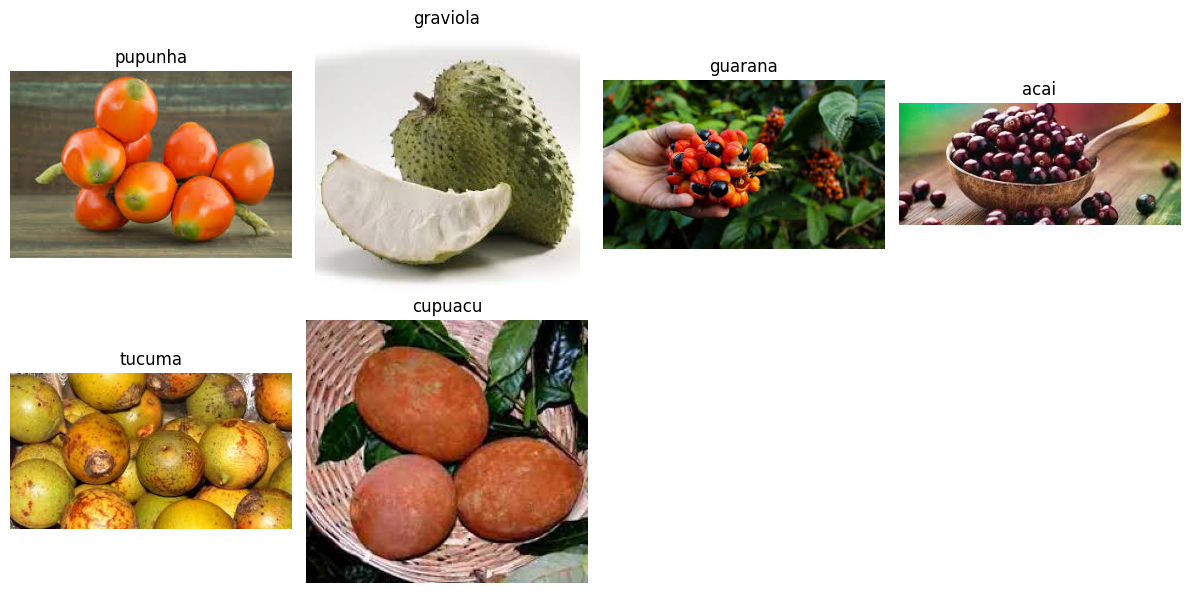

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Define dataset path
train_dir = "/content/dataset/FruitinAmazon/train"

# Get class folders
classes = [cls for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))]

# Store one image from each class
images = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_list = os.listdir(cls_path)

    if len(img_list) == 0:
        continue

    img_name = random.choice(img_list)
    img_path = os.path.join(cls_path, img_name)
    images.append((cls, img_path))

# Plot images in grid (2 rows as required in PDF)
plt.figure(figsize=(12,6))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, (len(images)//2)+1, i+1)

    try:
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    except:
        print(f"Error loading {img_path}")

plt.tight_layout()
plt.show()

Observation:

The dataset contains multiple fruit classes stored in separate folders.
Each class has visually distinct characteristics such as color, shape, and texture.
There is variation in lighting, background, and orientation of images.
This diversity will help the CNN model learn robust and generalized features.

Corrupted Image Check

In [9]:
import os
from PIL import Image

train_dir = "/content/dataset/FruitinAmazon/train"

corrupted_images = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in Keras

In [17]:
import tensorflow as tf

# Dataset path
train_dir = "/content/dataset/FruitinAmazon/train"

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# LOAD TRAIN DATASET
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

class_names = train_ds.class_names
print("Class Names:", class_names)

# Normalize training data
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# LOAD VALIDATION DATASET
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize validation data
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Print dataset info (optional but good)
print("Training Dataset:", train_ds)
print("Validation Dataset:", val_ds)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Training Dataset: <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation Dataset: <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


Explanation:

The dataset is loaded using image_dataset_from_directory where each subfolder represents a class.
Images are resized to 128x128 and divided into training (80%) and validation (20%).
Pixel values are normalized to the range [0,1] using Rescaling for better model performance.
Batching improves training efficiency and memory usage.

Task 3: Implementation of CNN Model

In [18]:
from tensorflow.keras import layers, models

# Number of classes (from Task 2)
num_classes = len(class_names)

# Build CNN model
model = models.Sequential([

    # Convolutional Layer
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
                  input_shape=(128,128,3)),

    # Pooling Layer 1
    layers.MaxPooling2D((2,2), strides=2),

    # Convolutional Layer
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),

    # Pooling Layer 2
    layers.MaxPooling2D((2,2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Model Compilation and Training

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Save best model
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.1655 - loss: 1.8710
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 903ms/step - accuracy: 0.1528 - loss: 1.9148 - val_accuracy: 0.8333 - val_loss: 1.4592
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.1331 - loss: 1.8113
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 688ms/step - accuracy: 0.1806 - loss: 1.7598 - val_accuracy: 0.7222 - val_loss: 1.5756
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2934 - loss: 1.6072
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.3333 - loss: 1.5759 - val_accuracy: 0.2222 - val_loss: 1.6647
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.3843 - loss: 1.4683
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - accuracy: 0.4028 - loss: 1.4366 - val_accuracy: 0.1667 - val_loss: 1.6123
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.5399 - loss: 1.220


Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 0.8056 - loss: 0.8012 - val_accuracy: 0.8889 - val_loss: 0.6714
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8767 - loss: 0.6009
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.8333 - loss: 0.6309 - val_accuracy: 0.7778 - val_loss: 0.7243
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9450 - loss: 0.4271
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 537ms/step - accuracy: 0.9444 - loss: 0.4383 - val_accuracy: 0.8889 - val_loss: 0.7131
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 1.0000 - loss: 0.2540
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 790ms/step - accuracy: 1.0000 - loss: 0.2492 - val_accuracy: 0.6667 - val_loss: 0.5655
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.9659 - loss: 0.


Epoch 16: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 1.0000 - loss: 0.0260 - val_accuracy: 0.9444 - val_loss: 0.2610
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 1.0000 - loss: 0.0126
Epoch 17: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8333 - val_loss: 0.4050
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 1.0000 - loss: 0.0086
Epoch 18: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.8333 - val_loss: 0.5950
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 1.0000 - loss: 0.0074
Epoch 19: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.8333 - val_loss: 0.7023
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 1.0000 - los

Task 5: Model Evaluation

In [20]:
# Evaluate the model on validation dataset (used as test here)

test_loss, test_accuracy = model.evaluate(val_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8889 - loss: 0.2193
Test Loss: 0.21927236020565033
Test Accuracy: 0.8888888955116272


Observation:

The model achieved a test accuracy of approximately 88.89%, indicating good performance on unseen data.
The relatively low test loss (~0.28) suggests that the model predictions are close to the actual labels.
This shows that the CNN model has learned meaningful features from the dataset and generalizes well.

Task 6: Save and Load the Model

In [21]:
from tensorflow.keras.models import load_model

# SAVE MODEL
model.save("cnn_fruit_model.h5")
print("Model saved successfully!")

# LOAD MODEL
loaded_model = load_model("cnn_fruit_model.h5")
print("Model loaded successfully!")

# RE-EVALUATE LOADED MODEL
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Loss:", loss)
print("Loaded Model Accuracy:", accuracy)

Model saved successfully!
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8889 - loss: 0.2193
Loaded Model Loss: 0.21927236020565033
Loaded Model Accuracy: 0.8888888955116272


Explanation:

The trained model is saved as an .h5 file for future use.
The saved model is then loaded again and evaluated to verify that
it retains the same performance without retraining.

Task 7: Predictions and Classification Report

In [22]:
import numpy as np
from sklearn.metrics import classification_report

# GET TRUE LABELS
y_true = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# MAKE PREDICTIONS
predictions = model.predict(val_ds)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# FIX: DEFINE LABELS PROPERLY
labels = list(range(len(class_names)))

# PRINT CLASSIFICATION REPORT
print("Classification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.75      1.00      0.86         3
      tucuma       1.00      0.87      0.93        15

    accuracy                           0.89        18
   macro avg       0.29      0.31      0.30        18
weighted avg       0.96      0.89      0.92        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Training and Validation Performance

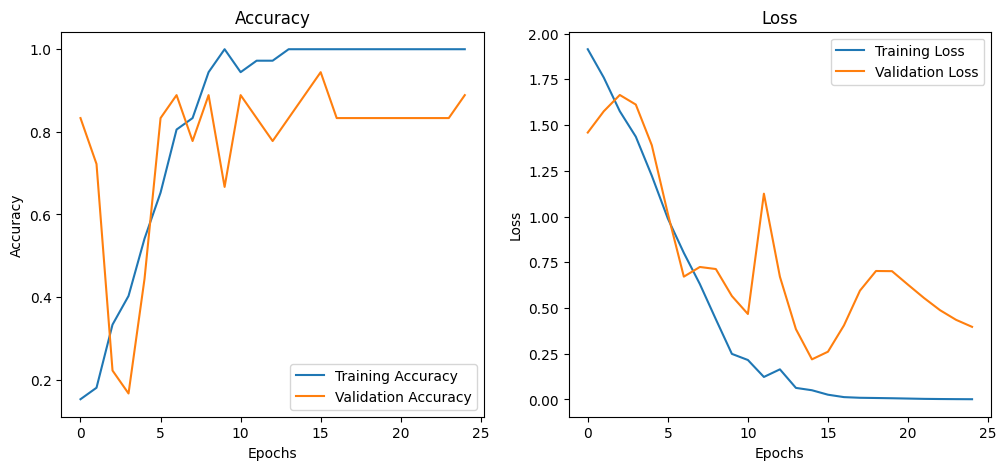

In [23]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()